In [1]:
# Proposal : Can we predict the winner of an eSports match successfully at the ten minute mark of the game?
# Prediction vs Causation : This model will predict the match outcomes based on early game indicators such as gold difference or objectives.
# It does not exactly mean the win or loss is directly guranteed because of these factors, but shows that these factors heavily impact it.

# Dateset : https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min
# N = 9,879 Features = 38

# Stakeholder : eSports coaches who want to view how various factors can be translated into their matches and help them prioritize 
# what to target in their own matches using the results from other competitive matches. 

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
import kagglehub

path = kagglehub.dataset_download("bobbyscience/league-of-legends-diamond-ranked-games-10-min")
file = os.path.join(path, "high_diamond_ranked_10min.csv")
df = pd.read_csv(file)

df = df.drop('gameId', axis=1)
print(df.shape)
print(df.head())
print(df.dtypes.head(10))

(9879, 39)
   blueWins  blueWardsPlaced  blueWardsDestroyed  blueFirstBlood  blueKills  \
0         0               28                   2               1          9   
1         0               12                   1               0          5   
2         0               15                   0               0          7   
3         0               43                   1               0          4   
4         0               75                   4               0          6   

   blueDeaths  blueAssists  blueEliteMonsters  blueDragons  blueHeralds  ...  \
0           6           11                  0            0            0  ...   
1           5            5                  0            0            0  ...   
2          11            4                  1            1            0  ...   
3           5            5                  1            0            1  ...   
4           6            6                  0            0            0  ...   

   redTowersDestroyed  redTotalGo

In [3]:
# Due to the data also coming from Riot Games API and providing full inputs and records, 
# if there were any missing values it would be due to MNAR. 

print("Missing Values : ", df.isnull().sum())

Missing Values :  blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds                    

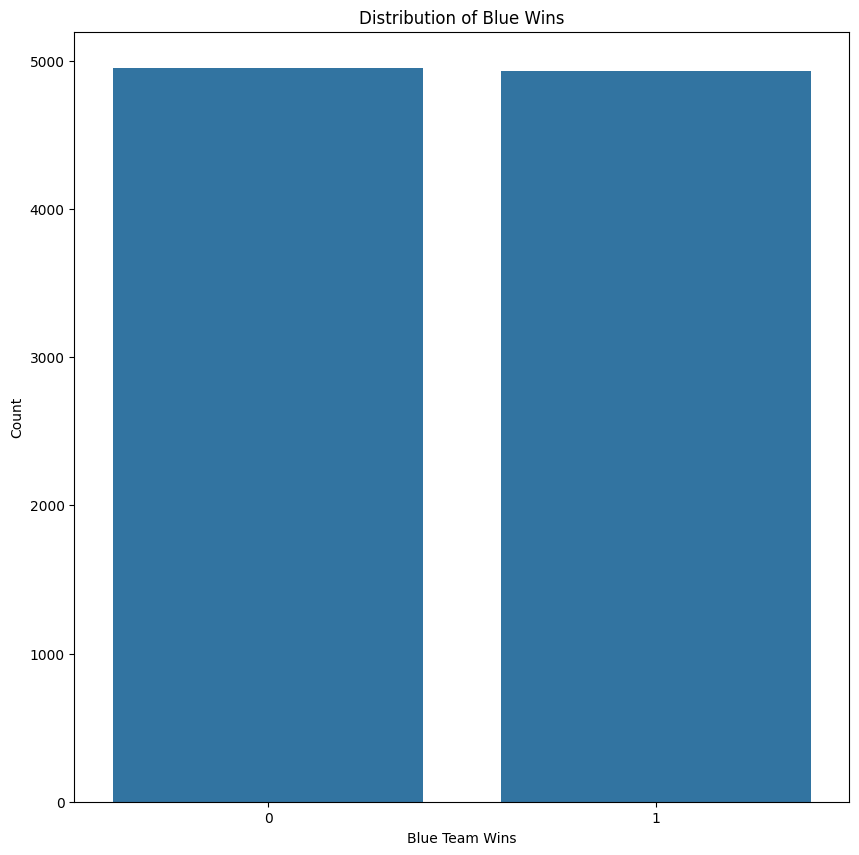

In [4]:
plt.figure(figsize=(10, 10))
sns.countplot(data=df, x='blueWins')
plt.title('Distribution of Blue Wins')
plt.xlabel('Blue Team Wins')
plt.ylabel('Count')
plt.show()

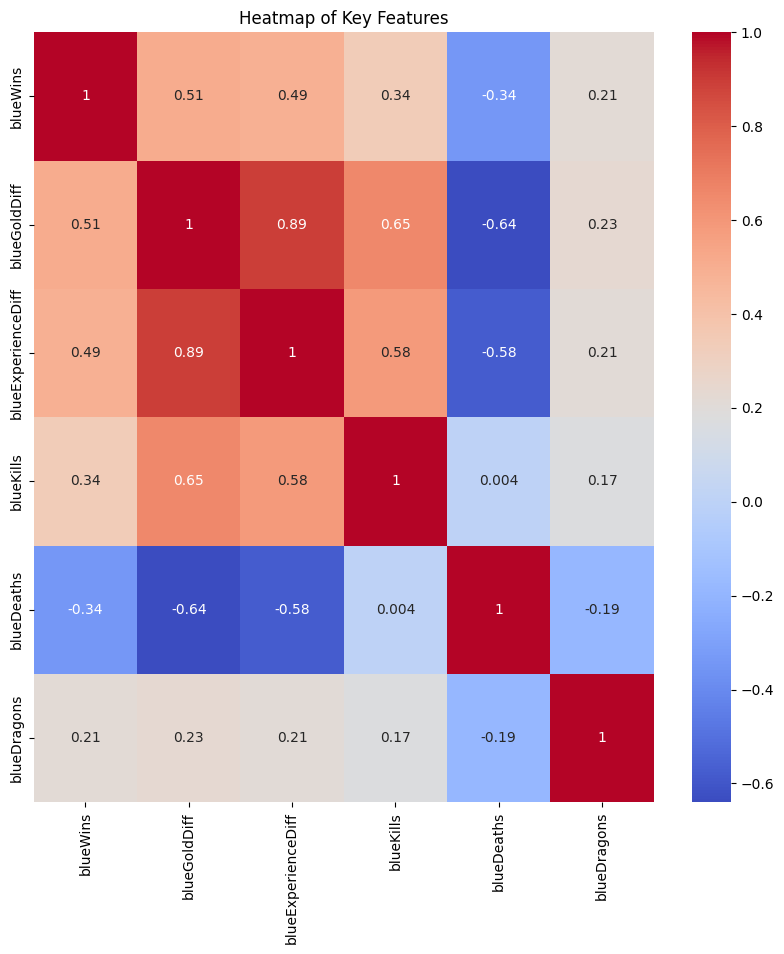

In [5]:
plt.figure(figsize=(10, 10))
features = ['blueWins', 'blueGoldDiff', 'blueExperienceDiff', 'blueKills', 'blueDeaths', 'blueDragons']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Key Features')
plt.show()

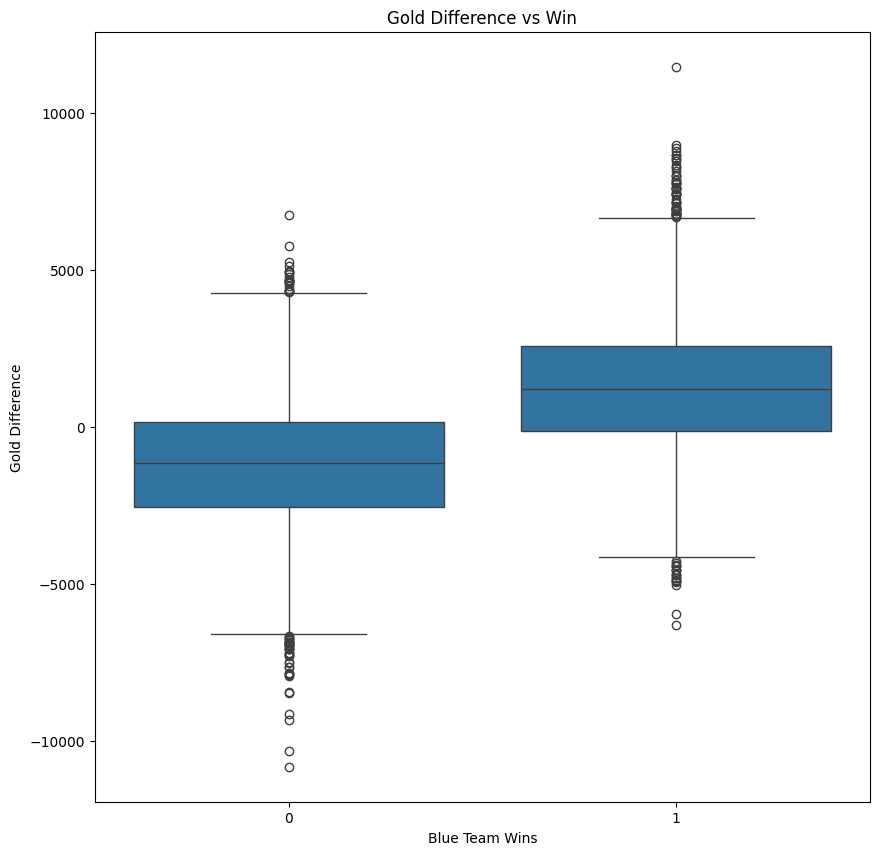

In [6]:
plt.figure(figsize=(10, 10))
sns.boxplot(data=df, x='blueWins', y='blueGoldDiff')
plt.title('Gold Difference vs Win')
plt.xlabel('Blue Team Wins')
plt.ylabel('Gold Difference')
plt.show()

In [7]:
# The data is extremely clean and appears to be obtained from an official source and shows 
# no missing data, making it very easy to use for models right away.

In [8]:
X = df.drop('blueWins', axis=1)
y = df['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(accuracy)
print(precision)
print(recall)

0.7282388663967612
0.7289156626506024
0.7311178247734139


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
import joblib
from sklearn.preprocessing import StandardScaler

# Example of retraining with subset
features = ['blueGoldDiff', 'blueExperienceDiff', 'blueKills', 'blueDragons']
X = df[features]
y = df['blueWins']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

# Save the model and scaler to files
joblib.dump(model, 'logreg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

2026-04-25 03:44:52.863 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 03:44:52.885 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-25 03:44:52.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 03:44:52.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 03:44:52.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 03:44:52.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 03:44:52.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25

DeltaGenerator()

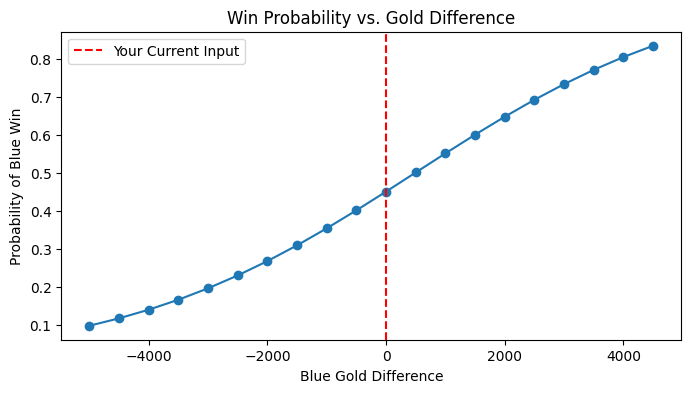

In [10]:
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trained model and scaler
model = joblib.load('logreg_model.pkl')
scaler = joblib.load('scaler.pkl')

# (Optional) Load a sample of data for the visualization
# df = pd.read_csv('high_diamond_ranked_10min.csv')

st.title("League of Legends 10-Min Match Predictor")
st.write("Adjust the early game stats below to predict the match outcome.")

# 2. Parameter Controls (Assignment Requirement 1)
st.sidebar.header("Match Parameters")
gold_diff = st.sidebar.slider("Blue Team Gold Difference", min_value=-10000, max_value=10000, value=0, step=100)
exp_diff = st.sidebar.slider("Blue Team Experience Difference", min_value=-10000, max_value=10000, value=0, step=100)
blue_kills = st.sidebar.number_input("Blue Team Kills", min_value=0, max_value=50, value=5)
blue_dragons = st.sidebar.selectbox("Blue Team Dragons Secured", options=[0, 1])

# Create a dataframe for the user input
input_data = pd.DataFrame({
    'blueGoldDiff': [gold_diff],
    'blueExperienceDiff': [exp_diff],
    'blueKills': [blue_kills],
    'blueDragons': [blue_dragons]
})

# Scale the input
input_scaled = scaler.transform(input_data)

# 3. Prediction output with uncertainty (Assignment Requirement 3)
st.subheader("Prediction")
if st.button("Predict Outcome"):
    # Get prediction and probabilities
    prediction = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]
    
    # In classification, the probability acts as your "confidence/uncertainty" measure
    blue_win_prob = probabilities[1] * 100
    red_win_prob = probabilities[0] * 100
    
    if prediction == 1:
        st.success(f"**Blue Team Wins!** (Confidence: {blue_win_prob:.2f}%)")
    else:
        st.error(f"**Red Team Wins!** (Confidence: {red_win_prob:.2f}%)")

# 4. Interactive Visualization (Assignment Requirement 2)
st.subheader("Feature Impact Analysis")
st.write("Watch how your selected Gold Difference impacts the probability of winning.")

# Create dynamic data for a chart based on user input
# We vary the gold difference while keeping user's other inputs constant
gold_range = range(-5000, 5000, 500)
probs = []

for g in gold_range:
    temp_input = pd.DataFrame({
        'blueGoldDiff': [g],
        'blueExperienceDiff': [exp_diff], # Fixed to user input
        'blueKills': [blue_kills],        # Fixed to user input
        'blueDragons': [blue_dragons]     # Fixed to user input
    })
    temp_scaled = scaler.transform(temp_input)
    prob = model.predict_proba(temp_scaled)[0][1] # Get probability of Blue Win
    probs.append(prob)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(gold_range), probs, marker='o', linestyle='-')
ax.axvline(x=gold_diff, color='r', linestyle='--', label='Your Current Input')
ax.set_xlabel("Blue Gold Difference")
ax.set_ylabel("Probability of Blue Win")
ax.set_title("Win Probability vs. Gold Difference")
ax.legend()
st.pyplot(fig)